In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD YOUR DATA
# ==========================================
# CHANGE THIS to your actual file name
file_path = 'CVChanges.xlsx' 

# Read the Excel file
df = pd.read_excel(file_path)


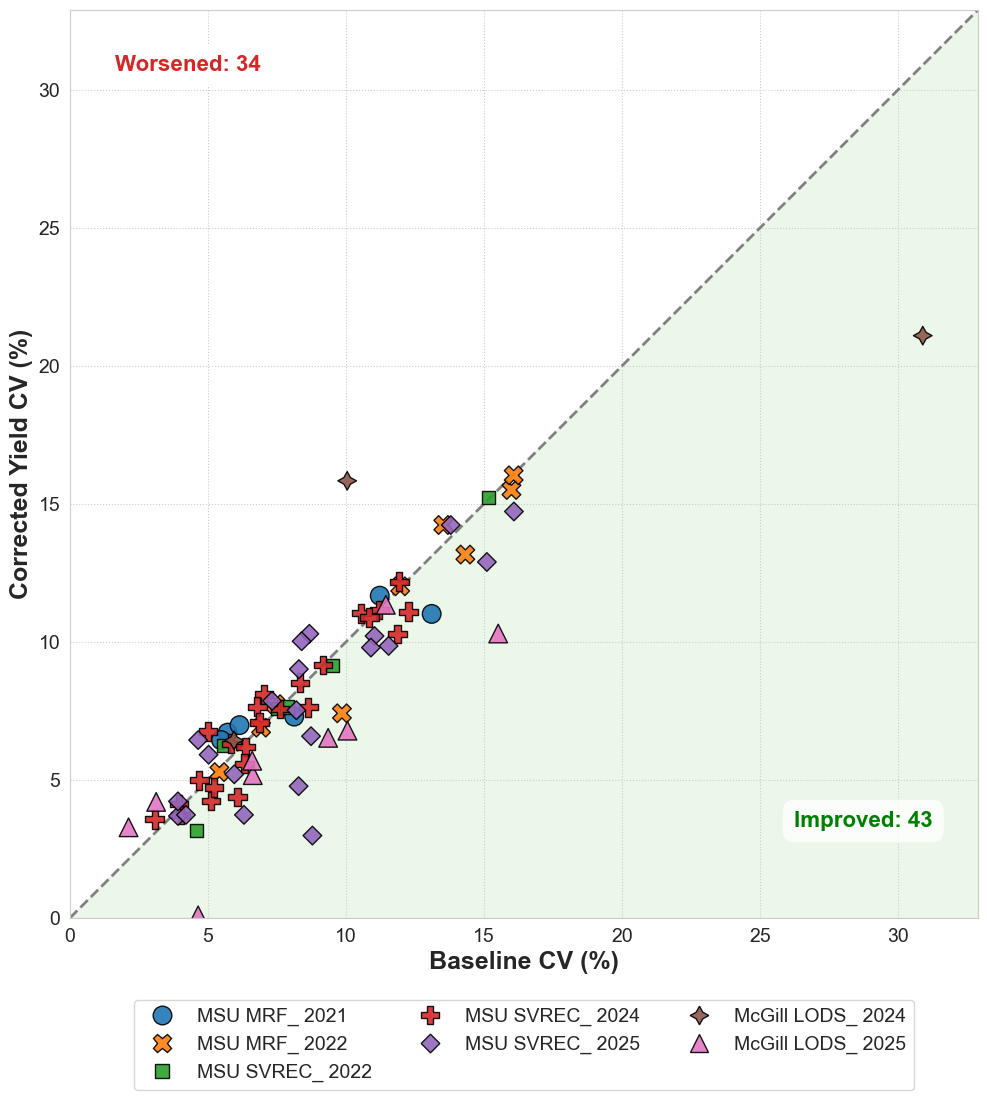

In [38]:
# 2. PREPARE THE DATA
# ==========================================
df['Group'] = df['Location'].astype(str) + " " + df['Year'].astype(str)

pivot_df = df.pivot_table(
    index=['Group', 'Location', 'Year', 'Experiment', 'Tier'], 
    columns='Trait', 
    values='Percent_CV'
).reset_index()

# Error handling
if 'CWT_A' not in pivot_df.columns or 'CorrectedYield' not in pivot_df.columns:
    print("Error: The script could not find 'CWT_A' or 'CorrectedYield' in your Trait column.")
else:
    # --- CALCULATE COUNTS ---
    # Improved: Corrected Yield is LOWER than Baseline (Below 1:1 line)
    n_improved = (pivot_df['CorrectedYield'] < pivot_df['CWT_A']).sum()
    # Worsened: Corrected Yield is HIGHER than Baseline (Above 1:1 line)
    n_worsened = (pivot_df['CorrectedYield'] > pivot_df['CWT_A']).sum()

    # ==========================================
    # 3. GENERATE THE PLOT
    # ==========================================
    plt.figure(figsize=(10, 11)) 
    sns.set_style("whitegrid", {'grid.linestyle': ':'})

    # Determine axis limits dynamically
    max_val = max(pivot_df['CWT_A'].max(), pivot_df['CorrectedYield'].max()) + 2
    min_val = 0

    # Draw the diagonal reference line (1:1 line)
    plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', linewidth=2, zorder=1)

    # Shade the "Improvement Zone" (Green area below the line)
    plt.fill_between([min_val, max_val], [min_val, max_val], min_val-10, color='#d9f0d3', alpha=0.5, zorder=0)

    # Create the Scatter Plot
    sns.scatterplot(
        data=pivot_df, 
        x='CWT_A', 
        y='CorrectedYield', 
        hue='Group', 
        style='Group',
        s=180,               # Slightly larger markers
        edgecolor='black', 
        linewidth=1,
        alpha=0.9,
        zorder=2
    )

    # --- ADD TEXT FOR COUNTS ---
    # "Improved" text goes in the bottom-right (Green Zone)
    plt.text(
        x=max_val * 0.95, 
        y=max_val * 0.1, 
        s=f'Improved: {n_improved}', 
        fontsize=16, 
        color='green', 
        fontweight='bold', 
        ha='right',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.5')
    )

    # "Worsened" text goes in the top-left (White Zone)
    plt.text(
        x=max_val * 0.05, 
        y=max_val * 0.95, 
        s=f'Worsened: {n_worsened}', 
        fontsize=16, 
        color='#d62728', # Red color 
        fontweight='bold', 
        ha='left', 
        va='top',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.5')
    )

    # ==========================================
    # 4. FINALIZE FORMATTING (UPDATED FONT SIZES)
    # ==========================================
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.gca().set_aspect('equal', adjustable='box') 

    # Increased Font Sizes
    plt.xlabel('Baseline CV (%)', fontsize=18, fontweight='bold')
    plt.ylabel('Corrected Yield CV (%)', fontsize=18, fontweight='bold')
    #plt.title('CV Comparison: Baseline vs Corrected', fontsize=20, fontweight='bold')
    
    # Increase the size of the numbers on the axis (ticks)
    plt.tick_params(axis='both', which='major', labelsize=14)

    # Legend Setup
    plt.legend(
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.08), 
        fancybox=True, 
        shadow=False, 
        ncol=3,               
        fontsize=14,          # Increased legend font size
        title=None            
    )

    plt.tight_layout()
    plt.savefig('CV_Parity_HorizontalLegend_WithCounts.png', dpi=350, bbox_inches='tight')
    plt.show()

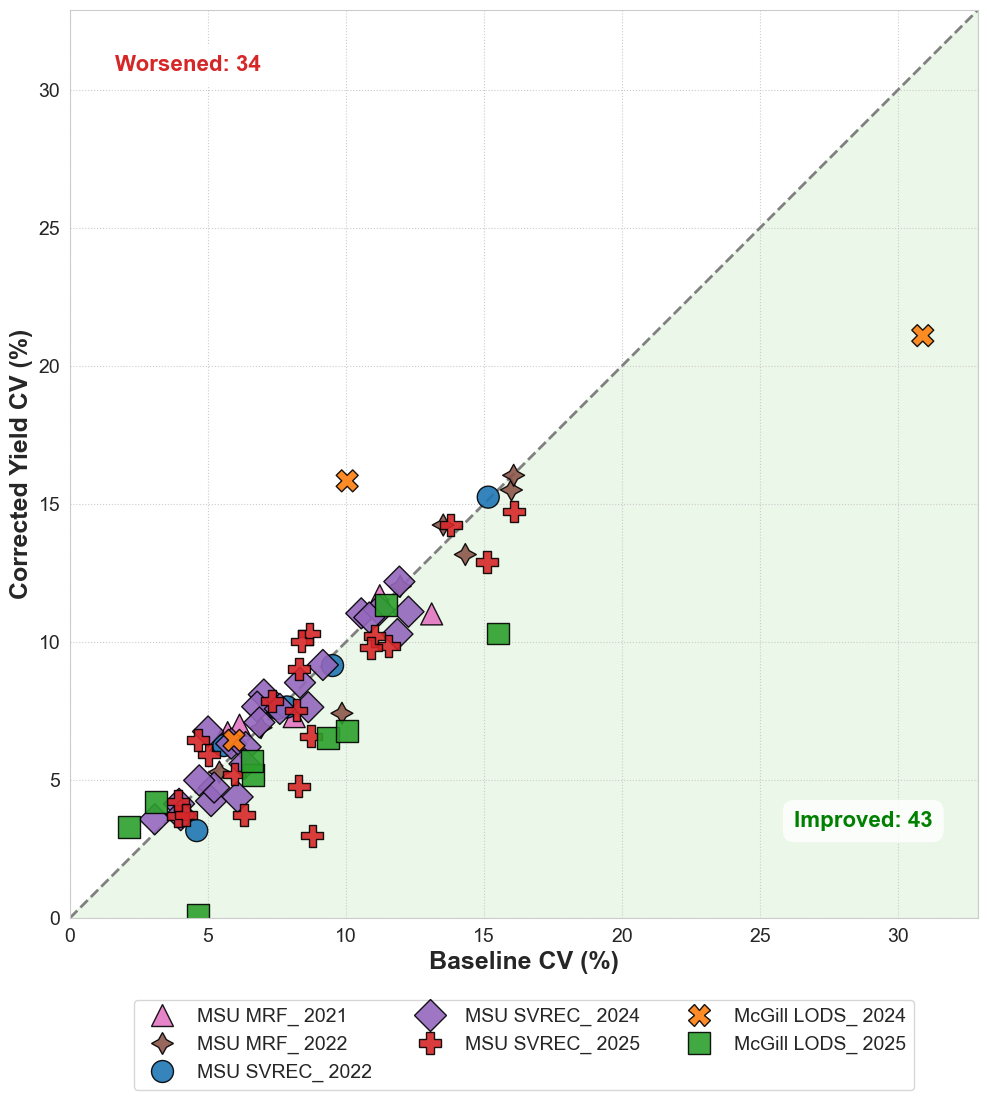

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ==========================================
# 2. PREPARE THE DATA
# ==========================================
# Maintaining your Group logic to avoid the ValueError from before
df['Group'] = df['Location'].astype(str) + " " + df['Year'].astype(str)

pivot_df = df.pivot_table(
    index=['Group', 'Location', 'Year', 'Experiment', 'Tier'], 
    columns='Trait', 
    values='Percent_CV'
).reset_index()

# Error handling
if 'CWT_A' not in pivot_df.columns or 'CorrectedYield' not in pivot_df.columns:
    print("Error: The script could not find 'CWT_A' or 'CorrectedYield' in your Trait column.")
else:
    # --- CALCULATE COUNTS ---
    n_improved = (pivot_df['CorrectedYield'] < pivot_df['CWT_A']).sum()
    n_worsened = (pivot_df['CorrectedYield'] > pivot_df['CWT_A']).sum()

    # ==========================================
    # 3. GENERATE THE PLOT
    # ==========================================
    plt.figure(figsize=(10, 11)) 
    sns.set_style("whitegrid", {'grid.linestyle': ':'})

    max_val = max(pivot_df['CWT_A'].max(), pivot_df['CorrectedYield'].max()) + 2
    min_val = 0

    plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', linewidth=2, zorder=1)
    plt.fill_between([min_val, max_val], [min_val, max_val], min_val-10, color='#d9f0d3', alpha=0.5, zorder=0)

    # --- UPDATED MARKERS AND COLORS ---
    custom_palette = {
        'MSU SVREC_ 2022': '#1f77b4', 'McGill LODS_ 2024': '#ff7f0e', 
        'McGill LODS_ 2025': '#2ca02c', 'MSU SVREC_ 2025': '#d62728', 
        'MSU SVREC_ 2024': '#9467bd', 'MSU MRF_ 2022': '#8c564b', # Brown
        'MSU MRF_ 2021': '#e377c2'
    }
    
    custom_markers = {
        'MSU SVREC_ 2022': 'o', 
        'McGill LODS_ 2024': 'X', 
        'McGill LODS_ 2025': 's', 
        'MSU SVREC_ 2025': 'P', 
        'MSU SVREC_ 2024': 'D', 
        'MSU MRF_ 2022': (4, 1, 0), # This creates the 4-pointed star/thin diamond from your image
        'MSU MRF_ 2021': '^'
    }

    sns.scatterplot(
        data=pivot_df, 
        x='CWT_A', 
        y='CorrectedYield', 
        hue='Group', 
        style='Group',
        palette=custom_palette,
        markers=custom_markers,
        s=250,                   # Increased size slightly to make the star prominent
        edgecolor='black', 
        linewidth=1,
        alpha=0.9,
        zorder=2
    )

    # --- TEXT FOR COUNTS ---
    plt.text(
        x=max_val * 0.95, y=max_val * 0.1, s=f'Improved: {n_improved}', 
        fontsize=16, color='green', fontweight='bold', ha='right',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.5')
    )

    plt.text(
        x=max_val * 0.05, y=max_val * 0.95, s=f'Worsened: {n_worsened}', 
        fontsize=16, color='#d62728', fontweight='bold', ha='left', va='top',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.5')
    )

    # ==========================================
    # 4. FINALIZE FORMATTING
    # ==========================================
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.gca().set_aspect('equal', adjustable='box') 

    plt.xlabel('Baseline CV (%)', fontsize=18, fontweight='bold')
    plt.ylabel('Corrected Yield CV (%)', fontsize=18, fontweight='bold')
    plt.tick_params(axis='both', which='major', labelsize=14)

    plt.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.08), 
    fancybox=True, 
    shadow=False, 
    ncol=3,               
    fontsize=14, 
    title=None            
)

plt.tight_layout()
plt.savefig('CVchangesNEW.png', dpi=350, bbox_inches='tight')

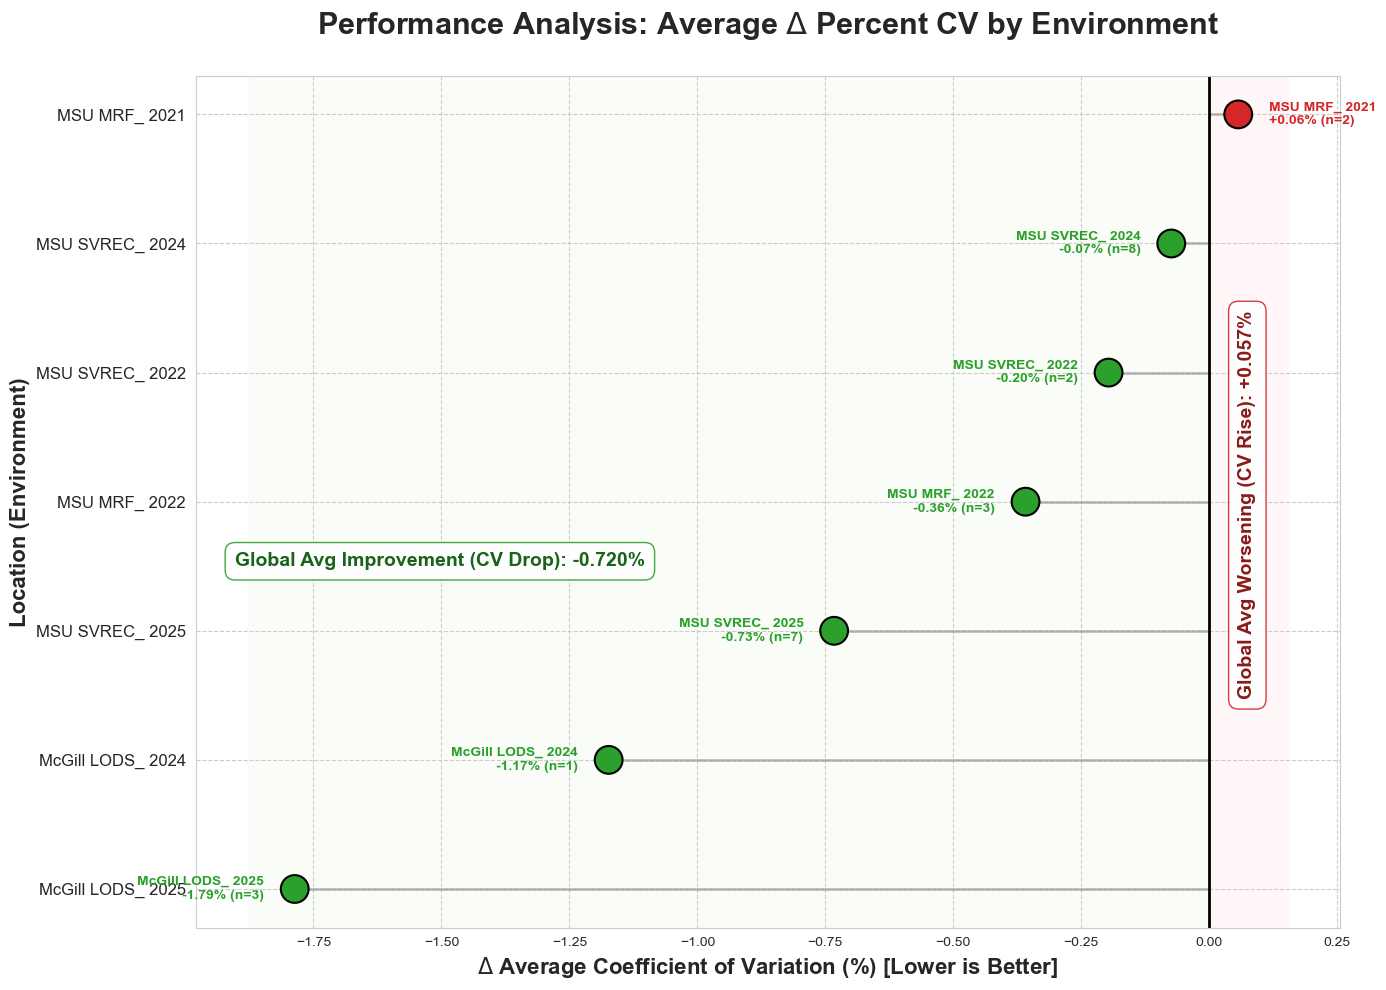

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. PREPARE THE DATA
# ==========================================
# Assuming df is pre-loaded with 'Percent_CV', 'Trait', and 'Location'
pivot_df = df.pivot_table(
    index=['Location', 'Year', 'Experiment'], 
    columns='Trait', 
    values='Percent_CV'
).reset_index()

# Define columns based on your script
baseline_cv = 'CWT_A'
corrected_cv = 'CorrectedYield'

# Calculate delta (Lower CV is better, so Delta = Corrected - Baseline)
# Negative values mean the CV decreased (Improvement)
pivot_df['Delta_CV'] = pivot_df[corrected_cv] - pivot_df[baseline_cv]

# Aggregate statistics by Environment (Location + Year)
pivot_df['Env'] = pivot_df['Location'].astype(str) + " " + pivot_df['Year'].astype(str)
location_stats = pivot_df.groupby('Env')['Delta_CV'].agg(['mean', 'count']).reset_index()
location_stats = location_stats.sort_values(by='mean', ascending=True).reset_index(drop=True)

# Calculate Global Averages for Reporting
# Improvement: Delta < 0 (CV decreased)
avg_improvement = location_stats[location_stats['mean'] < 0]['mean'].mean()
# Worsening: Delta > 0 (CV increased)
avg_worsening = location_stats[location_stats['mean'] >= 0]['mean'].mean()

# 2. GENERATE THE LOLLIPOP PLOT
# ==========================================
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid", {'grid.linestyle': '--', 'alpha': 0.4})

# Plot Stems and Lollipops (Green for decrease in CV, Red for increase)
colors = ['#2ca02c' if x < 0 else '#d62728' for x in location_stats['mean']]
plt.hlines(y=location_stats.index, xmin=0, xmax=location_stats['mean'], 
           color='gray', alpha=0.5, linewidth=2, zorder=1)
plt.scatter(location_stats['mean'], location_stats.index, 
            color=colors, s=400, edgecolor='black', linewidth=1.5, zorder=2)

# Annotations
plt.axvline(0, color='black', linewidth=2, linestyle='-')

# Label every bar with the environment and specific value
for i in range(len(location_stats)):
    row = location_stats.iloc[i]
    val = row['mean']
    env_name = row['Env']
    count = int(row['count'])
    
    # Position: Improvement (negative) on left, Worsening (positive) on right
    ha = 'right' if val < 0 else 'left'
    offset = -0.06 if val < 0 else 0.06
    
    plt.text(x=val + offset, y=i, s=f'{env_name}\n{val:+.2f}% (n={count})', 
             va='center', fontsize=10, fontweight='bold', ha=ha, color=colors[i])

# --- ADD GLOBAL NUMERIC AVERAGES ---
# Left Side: Improvement (Decrease in CV)
if not np.isnan(avg_improvement):
    plt.text(x=plt.xlim()[0]*0.8, y=len(location_stats)-4.5, 
             s=f'Global Avg Improvement (CV Drop): {avg_improvement:+.3f}%', 
             color='#1a631a', fontsize=14, fontweight='bold', ha='center',
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='#2ca02c', boxstyle='round,pad=0.5'))

# Right Side: Worsening (Increase in CV)
if not np.isnan(avg_worsening):
    plt.text(x=plt.xlim()[1]*0.5, y=+1.5, 
             s=f'Global Avg Worsening (CV Rise): {avg_worsening:+.3f}%', 
             color='#8a1a1a', fontsize=14, fontweight='bold', ha='center',rotation=90,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='#d62728', boxstyle='round,pad=0.5'))

# Scientific Labels and Titles
plt.title(r'Performance Analysis: Average $\Delta$ Percent CV by Environment', fontsize=22, fontweight='bold', pad=30)
plt.xlabel(r'$\Delta$ Average Coefficient of Variation (%) [Lower is Better]', fontsize=16, fontweight='bold')
plt.ylabel('Location (Environment)', fontsize=16, fontweight='bold')
plt.yticks(range(len(location_stats)), location_stats['Env'], fontsize=12)

# Zone Shading (Green for improvement zone on the left)
plt.axvspan(plt.xlim()[0], 0, color='#f7fcf5', alpha=0.7, zorder=0) 
plt.axvspan(0, plt.xlim()[1], color='#fff5f5', alpha=0.7, zorder=0) 

plt.tight_layout()
plt.savefig('CV_Performance_Report.png', dpi=400, bbox_inches='tight')
plt.show()

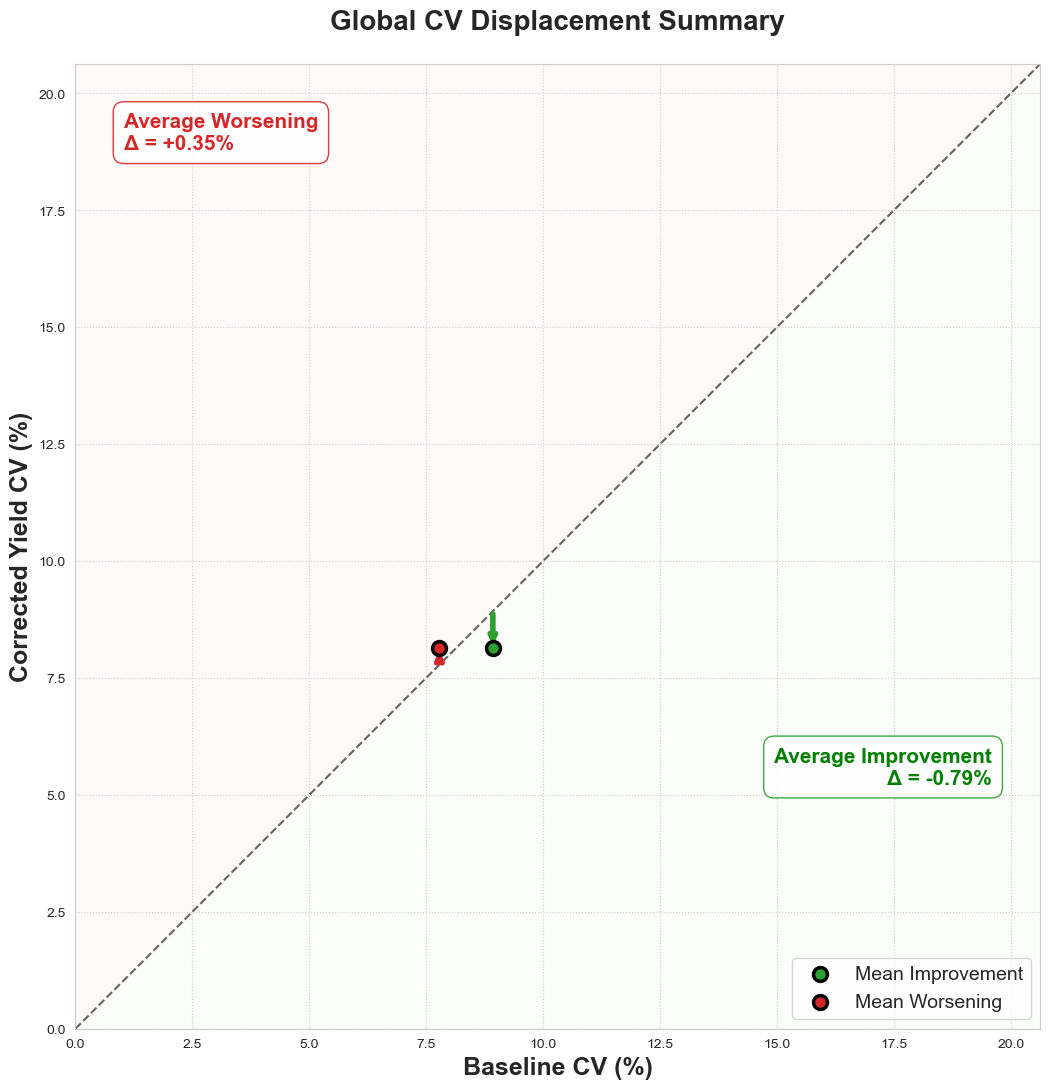

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. PREPARE THE DATA
# ==========================================
baseline_col = 'CWT_A'
corrected_col = 'CorrectedYield'

# Calculate displacement (Delta)
pivot_df['Delta'] = pivot_df[corrected_col] - pivot_df[baseline_col]

# Split into groups for centroid calculation
improved = pivot_df[pivot_df['Delta'] < 0]
worsened = pivot_df[pivot_df['Delta'] >= 0]

# Calculate Centroids (Means)
avg_imp_x, avg_imp_y = improved[baseline_col].mean(), improved[corrected_col].mean()
avg_wor_x, avg_wor_y = worsened[baseline_col].mean(), worsened[corrected_col].mean()

# 2. GENERATE THE PLOT
# ==========================================
plt.figure(figsize=(11, 11))
sns.set_style("whitegrid", {'grid.linestyle': ':'})

# Set limits with a small buffer
max_val = max(pivot_df[baseline_col].max(), pivot_df[corrected_col].max()) + 5
min_val = 0

# Draw 45-degree Identity Line (1:1)
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)

# Shading Zones
plt.fill_between([min_val, max_val], [min_val, max_val], min_val, color='#f7fcf5', alpha=0.6, zorder=0) 
plt.fill_between([min_val, max_val], [min_val, max_val], max_val, color='#fff5f5', alpha=0.6, zorder=0) 

# --- PLOT ONLY THE TWO AVERAGE POINTS ---
# Improved Centroid
plt.scatter(avg_imp_x, avg_imp_y, color='#2ca02c', s=100, edgecolor='black', linewidth=2.5, label='Mean Improvement', zorder=10)
plt.annotate('', xy=(avg_imp_x, avg_imp_y), xytext=(avg_imp_x, avg_imp_x),
             arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=4))

# Worsened Centroid
plt.scatter(avg_wor_x, avg_wor_y, color='#d62728', s=100, edgecolor='black', linewidth=2.5, label='Mean Worsening', zorder=10)
plt.annotate('', xy=(avg_wor_x, avg_wor_y), xytext=(avg_wor_x, avg_wor_x),
             arrowprops=dict(arrowstyle='->', color='#d62728', lw=4))

# --- CLEAN CORNER ANNOTATIONS (Fixed String Literals) ---
plt.text(max_val * 0.95, max_val * 0.25, 
         f'Average Improvement\nΔ = {improved["Delta"].mean():.2f}%',
         color='green', fontweight='bold', fontsize=15, ha='right', va='bottom',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='#2ca02c', boxstyle='round,pad=0.5'))

plt.text(max_val * 0.05, max_val * 0.95, 
         f'Average Worsening\nΔ = +{worsened["Delta"].mean():.2f}%',
         color='#d62728', fontweight='bold', fontsize=15, ha='left', va='top',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='#d62728', boxstyle='round,pad=0.5'))

# 3. FINALIZE FORMATTING
# ==========================================
plt.gca().set_aspect('equal')
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel('Baseline CV (%)', fontsize=18, fontweight='bold')
plt.ylabel('Corrected Yield CV (%)', fontsize=18, fontweight='bold')
plt.title('Global CV Displacement Summary', fontsize=20, fontweight='bold', pad=25)

# Minimalist Legend (No numbers, no n=)
plt.legend(loc='lower right', frameon=True, fontsize=14)

plt.tight_layout()
plt.savefig('CV_Centroid_Summary_Fixed.png', dpi=400, bbox_inches='tight')
plt.show()

In [42]:
#Heratibility

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD YOUR DATA
# ==========================================
# CHANGE THIS to your actual file name
file_path = 'h2_summary.xlsx' 

# Read the Excel file
df = pd.read_excel(file_path)

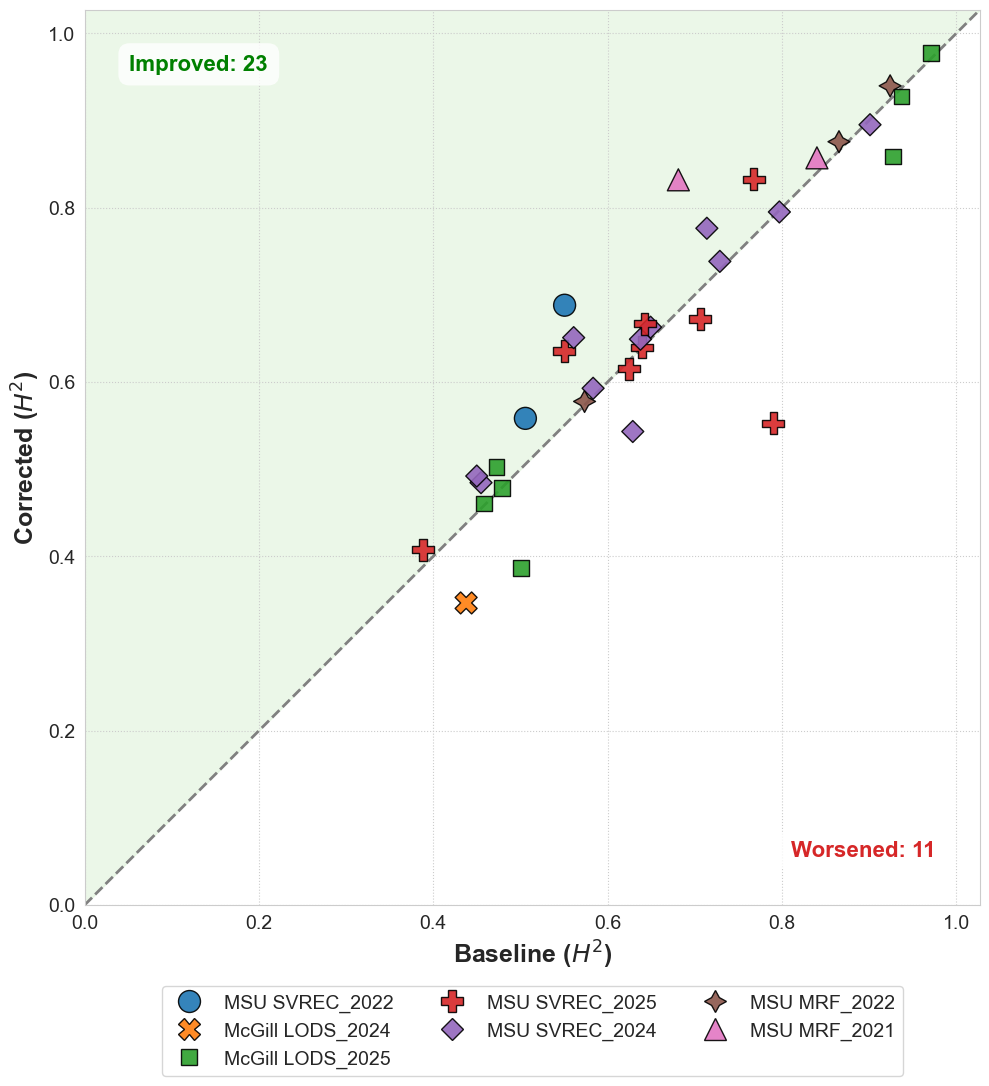

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PREPARE THE DATA
# ==========================================
df['Group'] = df['Program'].astype(str) + " " + df['Env'].astype(str)

baseline_col = 'H2_CWT_A'
corrected_col = 'H2_Corrected'

# --- CALCULATE COUNTS (REVERSED LOGIC) ---
# Improved: Corrected value is HIGHER than Baseline (Above 1:1 line)
n_improved = (df[corrected_col] > df[baseline_col]).sum()
# Worsened: Corrected value is LOWER than Baseline (Below 1:1 line)
n_worsened = (df[corrected_col] < df[baseline_col]).sum()

# ==========================================
# 2. GENERATE THE PLOT
# ==========================================
plt.figure(figsize=(10, 11)) 
sns.set_style("whitegrid", {'grid.linestyle': ':'})

# Determine axis limits
max_val = max(df[baseline_col].max(), df[corrected_col].max()) + 0.05
min_val = 0

# Draw the diagonal reference line
plt.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', linewidth=2, zorder=1)

# --- SHAPED SHADING (SWAPPED) ---
# Shade the "Improvement Zone" (Green area ABOVE the line)
plt.fill_between([min_val, max_val], [min_val, max_val], max_val, color='#d9f0d3', alpha=0.5, zorder=0)

# Create the Scatter Plot
sns.scatterplot(
    data=df, 
    x=baseline_col, 
    y=corrected_col, 
    hue='Group', 
    style='Group',
    s=250,               
    edgecolor='black', 
    linewidth=1,
    alpha=0.9,
    zorder=2
)

# --- ADD TEXT FOR COUNTS (REPOSITIONED) ---
# "Improved" text goes in the top-left (Green Zone)
plt.text(
    x=max_val * 0.05, 
    y=max_val * 0.95, 
    s=f'Improved: {n_improved}', 
    fontsize=16, 
    color='green', 
    fontweight='bold', 
    ha='left', 
    va='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.5')
)

# "Worsened" text goes in the bottom-right (White Zone)
plt.text(
    x=max_val * 0.95, 
    y=max_val * 0.05, 
    s=f'Worsened: {n_worsened}', 
    fontsize=16, 
    color='#d62728', 
    fontweight='bold', 
    ha='right', 
    va='bottom',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.5')
)

# ==========================================
# 3. FINALIZE FORMATTING
# ==========================================
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box') 

plt.xlabel('Baseline ($H^2$)', fontsize=18, fontweight='bold')
plt.ylabel('Corrected ($H^2$)', fontsize=18, fontweight='bold')
plt.tick_params(axis='both', which='major', labelsize=14)

plt.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.08), 
    fancybox=True, 
    shadow=False, 
    ncol=3,               
    fontsize=14, 
    title=None            
)

plt.tight_layout()
plt.savefig('Heratibility.png', dpi=350, bbox_inches='tight')

plt.show()

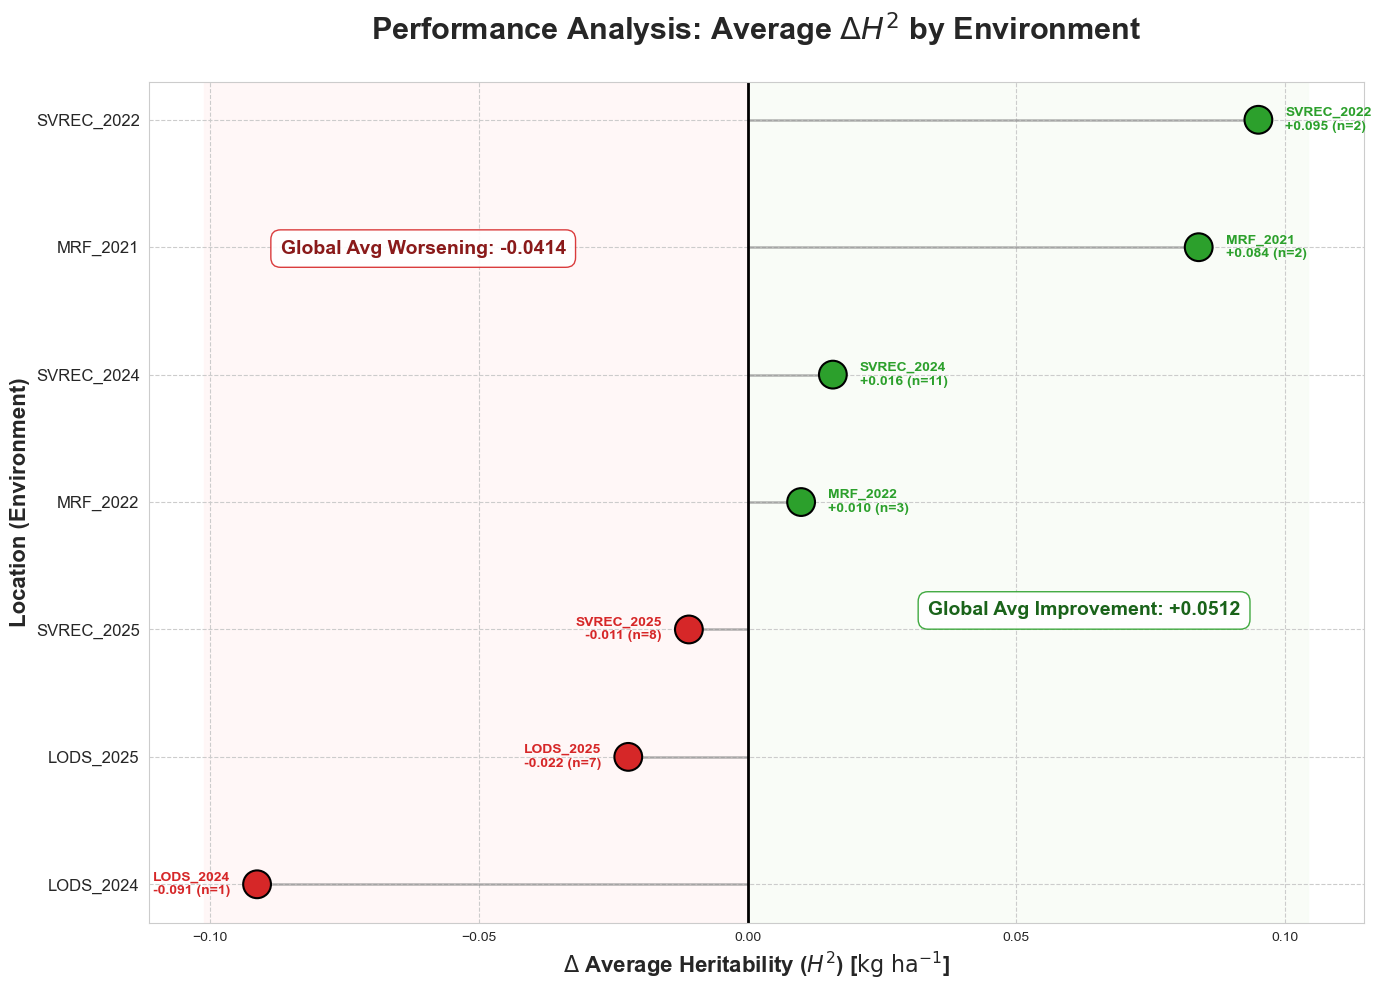

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PREPARE THE DATA
# ==========================================
baseline_col = 'H2_CWT_A'
corrected_col = 'H2_Corrected'

df['Delta_H2'] = df[corrected_col] - df[baseline_col]

# Aggregate statistics and sort
location_stats = df.groupby('Env')['Delta_H2'].agg(['mean', 'count']).reset_index()
location_stats = location_stats.sort_values(by='mean', ascending=True).reset_index(drop=True)

# Calculate Global Averages
avg_improvement = location_stats[location_stats['mean'] > 0]['mean'].mean()
avg_worsening = location_stats[location_stats['mean'] <= 0]['mean'].mean()

# 2. GENERATE THE FINAL PLOT
# ==========================================
plt.figure(figsize=(14, 10))
sns.set_style("whitegrid", {'grid.linestyle': '--', 'alpha': 0.4})

# Plot Stems and Lollipops
colors = ['#2ca02c' if x > 0 else '#d62728' for x in location_stats['mean']]
plt.hlines(y=location_stats.index, xmin=0, xmax=location_stats['mean'], 
           color='gray', alpha=0.5, linewidth=2, zorder=1)
plt.scatter(location_stats['mean'], location_stats.index, 
            color=colors, s=400, edgecolor='black', linewidth=1.5, zorder=2)

# --- FIX: LABEL POSITIONING ---
# We iterate using the range of the dataframe to ensure y-coordinate alignment
for i in range(len(location_stats)):
    row = location_stats.iloc[i]
    val = row['mean']
    env_name = row['Env']
    count = int(row['count'])
    
    # Determine horizontal position based on value
    ha = 'left' if val > 0 else 'right'
    offset = 0.005 if val > 0 else -0.005
    
    plt.text(
        x=val + offset, 
        y=i, 
        s=f'{env_name}\n{val:+.3f} (n={count})', 
        va='center', 
        fontsize=10, 
        fontweight='bold', 
        ha=ha, 
        color=colors[i]
    )

# 3. GLOBAL SUMMARY LABELS
# ==========================================
plt.axvline(0, color='black', linewidth=2, linestyle='-')

# Right side (Improvement)
plt.text(x=plt.xlim()[1]*0.6, y=len(location_stats)-4.89, 
         s=f'Global Avg Improvement: {avg_improvement:+.4f}', 
         color='#1a631a', fontsize=14, fontweight='bold', ha='center',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='#2ca02c', boxstyle='round,pad=0.5'))

# Left side (Worsening)
plt.text(x=plt.xlim()[0]*0.6, y=+4.95, 
         s=f'Global Avg Worsening: {avg_worsening:+.4f}', 
         color='#8a1a1a', fontsize=14, fontweight='bold', ha='center',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='#d62728', boxstyle='round,pad=0.5'))

# 4. FINALIZE FORMATTING
# ==========================================
plt.yticks(range(len(location_stats)), location_stats['Env'], fontsize=12)
plt.title(r'Performance Analysis: Average $\Delta H^2$ by Environment', fontsize=22, fontweight='bold', pad=30)
plt.xlabel(r'$\Delta$ Average Heritability ($H^2$) [$\mathrm{kg \ ha^{-1}}$]', fontsize=16, fontweight='bold')
plt.ylabel('Location (Environment)', fontsize=16, fontweight='bold')

plt.axvspan(0, plt.xlim()[1], color='#f7fcf5', alpha=0.7, zorder=0) 
plt.axvspan(plt.xlim()[0], 0, color='#fff5f5', alpha=0.7, zorder=0) 

plt.tight_layout()
plt.savefig('Heratibility_aver.png', dpi=350, bbox_inches='tight')

plt.show()

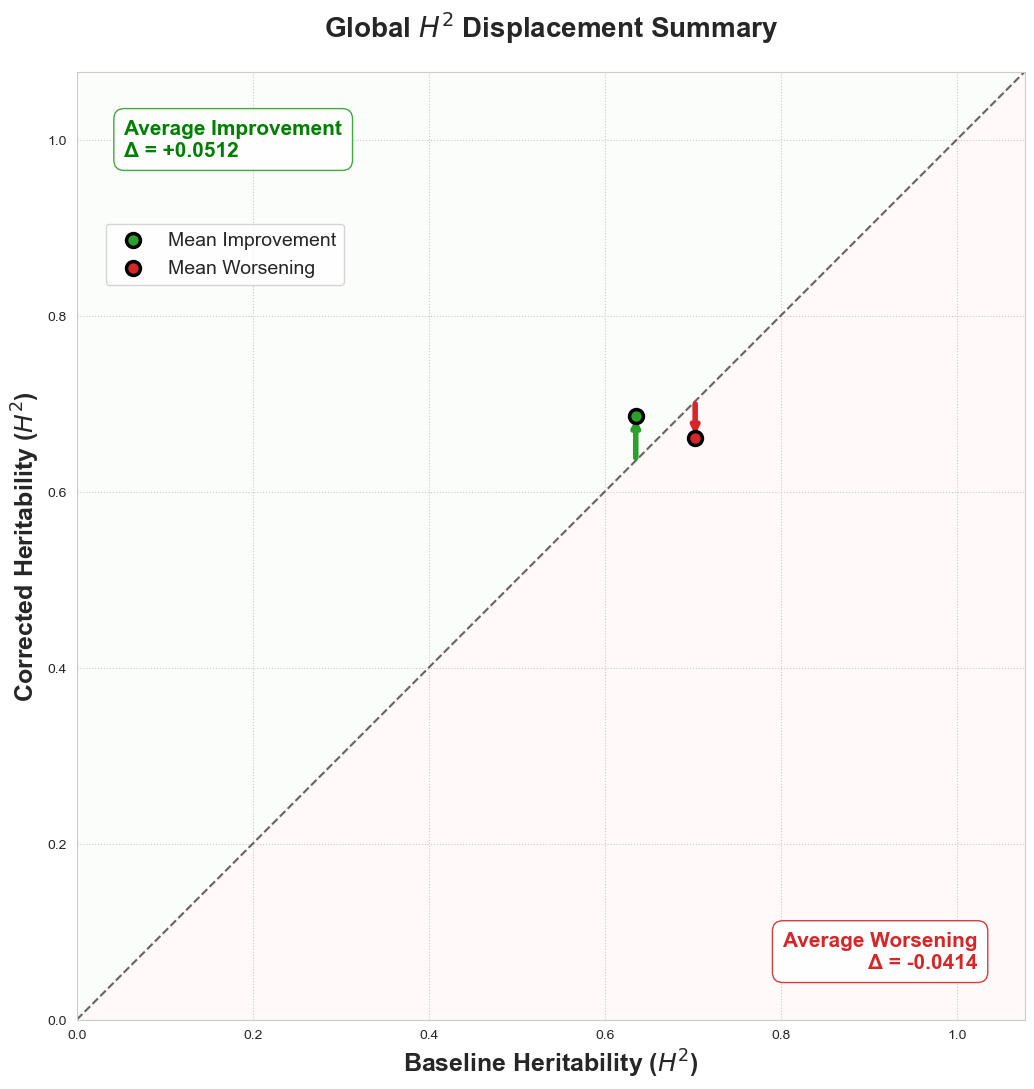

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. PREPARE THE DATA
# ==========================================
baseline_col = 'H2_CWT_A'
corrected_col = 'H2_Corrected'

# Calculate displacement (Delta)
df['Delta'] = df[corrected_col] - df[baseline_col]

# Identify Improved vs Worsened groups based on Delta
improved = df[df['Delta'] > 0]
worsened = df[df['Delta'] <= 0]

# --- SET REFERENCE CENTROIDS ---
# For Improvement side: Target delta is +0.0512
avg_imp_x = improved[baseline_col].mean()
avg_imp_y = avg_imp_x + 0.0512  # Set y based on the target improvement

# For Worsening side: Target delta is -0.0414
avg_wor_x = worsened[baseline_col].mean()
avg_wor_y = avg_wor_x - 0.0414  # Set y based on the target worsening

# 2. GENERATE THE PLOT
# ==========================================
plt.figure(figsize=(11, 11))
sns.set_style("whitegrid", {'grid.linestyle': ':'})

# Set limits with a buffer for professional framing
max_val = max(df[baseline_col].max(), df[corrected_col].max()) + 0.1
min_val = 0

# Draw 45-degree Identity Line (1:1)
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)

# Shading Zones (Green above for H2 gain, Red below for H2 loss)
plt.fill_between([min_val, max_val], [min_val, max_val], max_val, color='#f7fcf5', alpha=0.6, zorder=0) 
plt.fill_between([min_val, max_val], [min_val, max_val], min_val, color='#fff5f5', alpha=0.6, zorder=0) 

# --- PLOT CENTROIDS ---
# Improved Centroid (Green)
plt.scatter(avg_imp_x, avg_imp_y, color='#2ca02c', s=100, edgecolor='black', linewidth=2.5, label='Mean Improvement', zorder=10)
plt.annotate('', xy=(avg_imp_x, avg_imp_y), xytext=(avg_imp_x, avg_imp_x),
             arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=4))

# Worsened Centroid (Red)
plt.scatter(avg_wor_x, avg_wor_y, color='#d62728', s=100, edgecolor='black', linewidth=2.5, label='Mean Worsening', zorder=10)
plt.annotate('', xy=(avg_wor_x, avg_wor_y), xytext=(avg_wor_x, avg_wor_x),
             arrowprops=dict(arrowstyle='->', color='#d62728', lw=4))

# --- CORNER ANNOTATIONS WITH TARGET VALUES ---
plt.text(max_val * 0.05, max_val * 0.95, 
         f'Average Improvement\nΔ = +0.0512',
         color='green', fontweight='bold', fontsize=15, ha='left', va='top',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='#2ca02c', boxstyle='round,pad=0.5'))

plt.text(max_val * 0.95, max_val * 0.05, 
         f'Average Worsening\nΔ = -0.0414',
         color='#d62728', fontweight='bold', fontsize=15, ha='right', va='bottom',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='#d62728', boxstyle='round,pad=0.5'))

# 3. FINALIZE FORMATTING
# ==========================================
plt.gca().set_aspect('equal')
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xlabel(r'Baseline Heritability ($H^2$)', fontsize=18, fontweight='bold')
plt.ylabel(r'Corrected Heritability ($H^2$)', fontsize=18, fontweight='bold')
plt.title(r'Global $H^2$ Displacement Summary', fontsize=20, fontweight='bold', pad=25)

# Minimalist Legend
plt.legend(loc='upper left', frameon=True, fontsize=14, bbox_to_anchor=(0.02, 0.85))

plt.tight_layout()
plt.savefig('H2_Target_Centroids.png', dpi=400, bbox_inches='tight')
plt.show()